# **EfficientNet Pre-trained Raw Binary Model**

## Libraries

In [ ]:
# Libraries
import pandas as pd
from tensorflow import keras
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score

from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC

from focal_loss import BinaryFocalLoss

from deep.constants import DATA_DIR, IMAGE_DIR, IMG_SIZE, BATCH_SIZE, SEED
from deep.preprocess.album_augmenter import compute_effective_class_weights
from deep.models.aux_funcs import split_data, show_augmented_images, smart_resize_img, get_fitted_model_metrics, plot_metrics, plot_confusion_matrix
from deep.models.models import efficient_net

2025-04-23 11:18:53.076784: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 11:18:53.107469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 11:18:53.140281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 11:18:53.147388: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 11:18:53.165879: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing and Modelling

In [ ]:
# # Performing the splits
# train_df, val_df, test_df = split_data(data, 'is_animal')

In [ ]:
# # Changing target to string
# train_df['is_animal'] = train_df['is_animal'].astype(str)
# val_df['is_animal'] = val_df['is_animal'].astype(str)
# test_df['is_animal'] = test_df['is_animal'].astype(str)

In [ ]:
# train_datagen = ImageDataGenerator(
#     rotation_range=90,
#     shear_range=0.2,
#     brightness_range=[0.8, 1.2],
#     horizontal_flip=True,
#     channel_shift_range=30.0,
#     zoom_range=(0.8, 1.2),
#     fill_mode='nearest',
#     preprocessing_function=smart_resize_img
# )
# test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# # Train generator
# binary_train_generator = train_datagen.flow_from_dataframe(
#     dataframe=train_df,
#     directory=f'{IMAGE_DIR}',
#     x_col='file_path',
#     y_col='is_animal',
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     seed=SEED,
#     shuffle=True  # shuffle for training
# )

# # Validation generator
# binary_val_generator = test_datagen.flow_from_dataframe(
#     dataframe=val_df,
#     directory=f'{IMAGE_DIR}',
#     x_col='file_path',
#     y_col='is_animal',
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     shuffle=False
# )

# # Test generator
# binary_test_generator = test_datagen.flow_from_dataframe(
#     dataframe=test_df,
#     directory=f'{IMAGE_DIR}',
#     x_col='file_path',
#     y_col='is_animal',
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     shuffle=False
)

Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


I0000 00:00:1745403539.030068   10557 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745403539.098584   10557 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745403539.098851   10557 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745403539.100377   10557 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

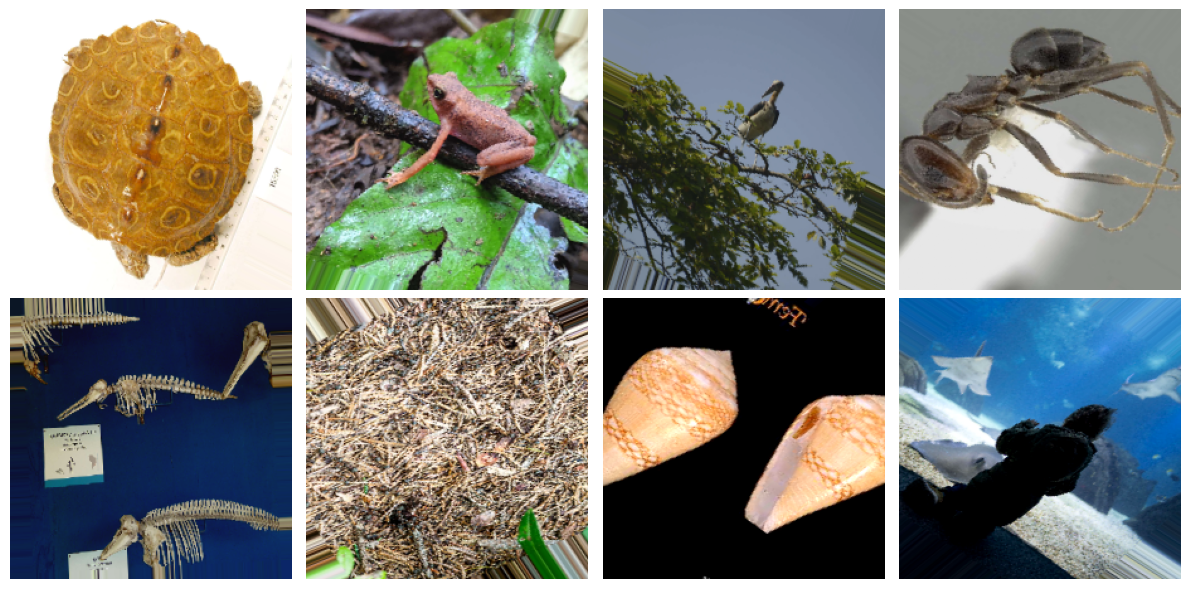

In [ ]:
# # Show augmented images - rerun for new batch
# show_augmented_images(binary_train_generator, num_images=8)

## Modelling

In [ ]:
# # Compute class weights
# class_weights = compute_effective_class_weights(train_df, 'is_animal')

### Raw Model

In [ ]:
# # Build the model
# binary_model = efficient_net()

In [ ]:
# # Compiling the model
# binary_model.compile(
#     optimizer=RMSprop(learning_rate=0.001)
#     ,loss=BinaryFocalLoss(
#         gamma=5
#         ,pos_weight=class_weights['1'] / (class_weights['0'] + class_weights['1'])
#     )
#     ,metrics=['accuracy', AUC(), 'precision', 'recall']
# )

In [ ]:
# # Fit the model
# fitted_binary = binary_model.fit(
#     binary_train_generator
#     ,validation_data=binary_val_generator
#     ,epochs=5
#     ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
#     ,validation_steps=int(np.ceil(len(val_df) / BATCH_SIZE))
#     ,class_weight=class_weights
#     ,callbacks=[
#         EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#         ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
#     ]
#     ,verbose=1
# )

In [ ]:
# get_fitted_model_metrics(fitted_binary)

In [ ]:
# plot_metrics(fitted_binary)

In [ ]:
# # Make predictions
# predictions = binary_model.predict(
#     binary_test_generator
#     ,steps=len(binary_test_generator)
#     ,verbose=1
# )

In [ ]:
# # Get the true labels
# y_true = binary_test_generator.labels

# # Convert predictions to class labels
# y_pred = (predictions > 0.5).astype(int).flatten()

# # Calculate metrics
# print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"Precision: {precision_score(y_true, y_pred):.4f}")
# print(f"Recall: {recall_score(y_true, y_pred):.4f}")

In [ ]:
# plot_confusion_matrix(y_true, y_pred, data['is_animal'].unique())

### Model with Regularization

In [17]:
# Build the model
binary_reg_model = efficient_net(regularizer=True)

In [18]:
# Compiling the model
binary_reg_model.compile(
    optimizer=RMSprop(learning_rate=0.001)
    ,loss=BinaryFocalLoss(
        gamma=5
        ,pos_weight=class_weights['1'] / (class_weights['0'] + class_weights['1'])
    )
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [19]:
# Fit the model
fitted_reg_binary = binary_reg_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,validation_steps=int(np.ceil(len(val_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

Epoch 1/5
226/255 ━━━━━━━━━━━━━━━━━━━━ 1:22 3s/step - accuracy: 0.7252 - auc_1: 0.4976 - loss: 0.0913 - precision: 0.9234 - recall: 0.7664

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


255/255 ━━━━━━━━━━━━━━━━━━━━ 919s 3s/step - accuracy: 0.7415 - auc_1: 0.4992 - loss: 0.0867 - precision: 0.9240 - recall: 0.7849 - val_accuracy: 0.0709 - val_auc_1: 0.4866 - val_loss: 0.0157 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 811s 3s/step - accuracy: 0.9359 - auc_1: 0.4807 - loss: 0.0089 - precision: 0.9360 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc_1: 0.4840 - val_loss: 0.0062 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 699s 3s/step - accuracy: 0.9334 - auc_1: 0.4803 - loss: 0.0059 - precision: 0.9341 - recall: 0.9991 - val_accuracy: 0.0709 - val_auc_1: 0.5286 - val_loss: 0.0087 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 772s 3s/step - accuracy: 0.9297 - auc_1: 0.5067 - loss: 0.0059 - precision: 0.9297 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_1: 0.5309 - 

In [20]:
get_fitted_model_metrics(fitted_reg_binary)

Train Loss: 0.005924803204834461
Validation Loss: 0.005965001415461302
Train Accuracy:0.9294305443763733
Validation Accuracy: 0.9291174411773682


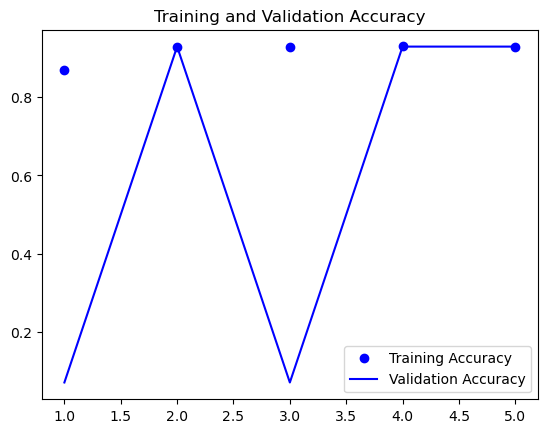

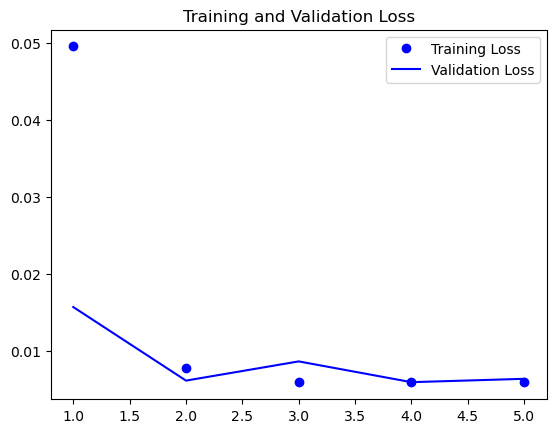

In [21]:
plot_metrics(fitted_reg_binary)

In [22]:
# Make predictions
reg_predictions = binary_reg_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step


In [23]:
# Get the true labels
reg_y_true = binary_test_generator.labels

# Convert predictions to class labels
reg_y_pred = (reg_predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(reg_y_true, reg_y_pred):.4f}")
print(f"Precision: {precision_score(reg_y_true, reg_y_pred):.4f}")
print(f"Recall: {recall_score(reg_y_true, reg_y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


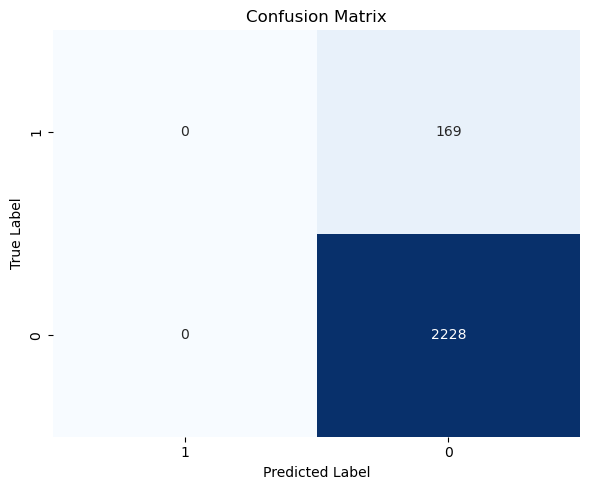

In [24]:
plot_confusion_matrix(reg_y_true, reg_y_pred, data['is_animal'].unique())

### Model with Dropout

In [25]:
# Build the model
binary_drop_model = efficient_net(dropout=True)

In [26]:
# Compiling the model
binary_drop_model.compile(
    optimizer=RMSprop(learning_rate=0.001)
    ,loss=BinaryFocalLoss(
        gamma=5
        ,pos_weight=class_weights['1'] / (class_weights['0'] + class_weights['1'])
    )
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 20

In [27]:
# Fit the model
fitted_drop_binary = binary_drop_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,validation_steps=int(np.ceil(len(val_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

Epoch 1/5
218/255 ━━━━━━━━━━━━━━━━━━━━ 1:26 2s/step - accuracy: 0.6630 - auc_2: 0.5170 - loss: 0.0264 - precision: 0.9292 - recall: 0.6900

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


255/255 ━━━━━━━━━━━━━━━━━━━━ 739s 3s/step - accuracy: 0.6728 - auc_2: 0.5161 - loss: 0.0254 - precision: 0.9292 - recall: 0.7012 - val_accuracy: 0.0709 - val_auc_2: 0.5320 - val_loss: 0.0130 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 696s 3s/step - accuracy: 0.8462 - auc_2: 0.4820 - loss: 0.0085 - precision: 0.9294 - recall: 0.9031 - val_accuracy: 0.9291 - val_auc_2: 0.5000 - val_loss: 0.0061 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 862s 3s/step - accuracy: 0.9291 - auc_2: 0.5144 - loss: 0.0060 - precision: 0.9291 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.5000 - val_loss: 0.0059 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 812s 3s/step - accuracy: 0.9310 - auc_2: 0.4963 - loss: 0.0059 - precision: 0.9312 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc_2: 0.5000 - val_loss

In [28]:
get_fitted_model_metrics(fitted_drop_binary)

Train Loss: 0.005960692651569843
Validation Loss: 0.005910237319767475
Train Accuracy:0.9294305443763733
Validation Accuracy: 0.9291174411773682


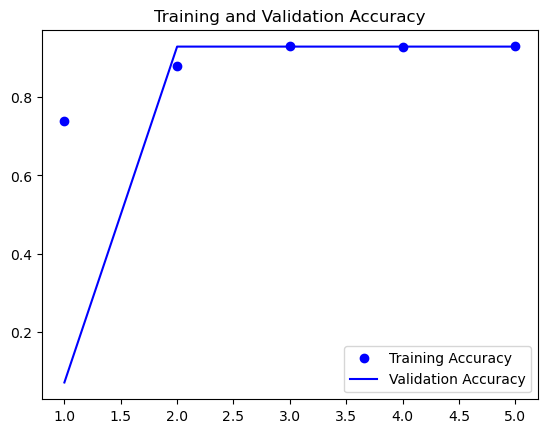

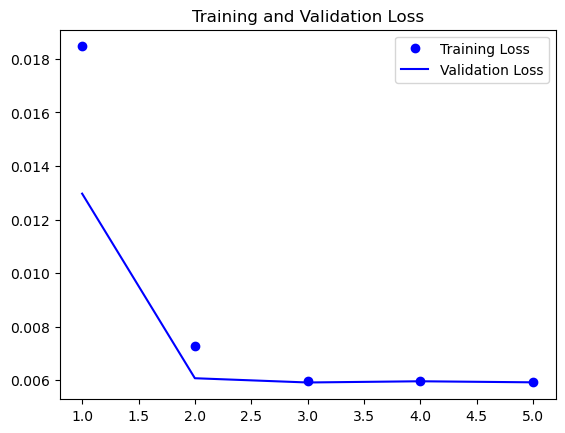

In [29]:
plot_metrics(fitted_drop_binary)

In [30]:
# Make predictions
drop_predictions = binary_drop_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step


In [31]:
# Get the true labels
drop_y_true = binary_test_generator.labels

# Convert predictions to class labels
drop_y_pred = (drop_predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(drop_y_true, drop_y_pred):.4f}")
print(f"Precision: {precision_score(drop_y_true, drop_y_pred):.4f}")
print(f"Recall: {recall_score(drop_y_true, drop_y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


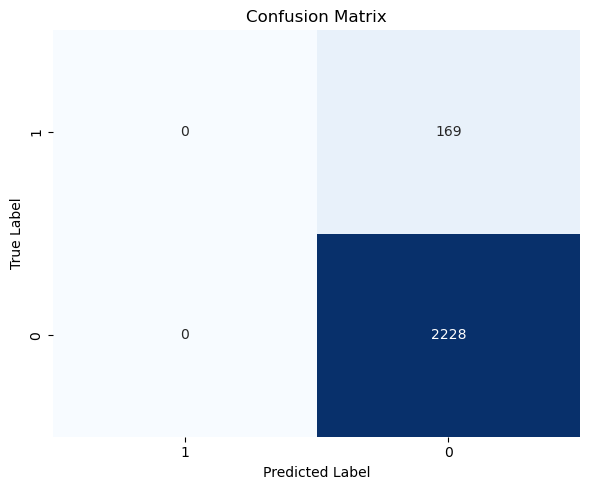

In [32]:
plot_confusion_matrix(drop_y_true, drop_y_pred, data['is_animal'].unique())

### Model with Regularization and Dropout

In [33]:
# Build the model
binary_reg_drop_model = efficient_net(regularizer=True, dropout=True)

In [34]:
# Compiling the model
binary_reg_drop_model.compile(
    optimizer=RMSprop(learning_rate=0.001)
    ,loss=BinaryFocalLoss(
        gamma=5
        ,pos_weight=class_weights['1'] / (class_weights['0'] + class_weights['1'])
    )
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [35]:
# Fit the model
fitted_reg_drop_binary = binary_reg_drop_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,validation_steps=int(np.ceil(len(val_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

Epoch 1/5
 79/255 ━━━━━━━━━━━━━━━━━━━━ 7:36 3s/step - accuracy: 0.5484 - auc_3: 0.5499 - loss: 0.1596 - precision: 0.9408 - recall: 0.5482

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


255/255 ━━━━━━━━━━━━━━━━━━━━ 792s 3s/step - accuracy: 0.6555 - auc_3: 0.5322 - loss: 0.1115 - precision: 0.9364 - recall: 0.6755 - val_accuracy: 0.9291 - val_auc_3: 0.4688 - val_loss: 0.0391 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.8223 - auc_3: 0.4911 - loss: 0.0128 - precision: 0.9267 - recall: 0.8777 - val_accuracy: 0.0709 - val_auc_3: 0.4859 - val_loss: 0.0179 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 697s 3s/step - accuracy: 0.8787 - auc_3: 0.4985 - loss: 0.0071 - precision: 0.9306 - recall: 0.9400 - val_accuracy: 0.9291 - val_auc_3: 0.4917 - val_loss: 0.0069 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
255/255 ━━━━━━━━━━━━━━━━━━━━ 684s 3s/step - accuracy: 0.9270 - auc_3: 0.5006 - loss: 0.0060 - precision: 0.9287 - recall: 0.9981 - val_accuracy: 0.9291 - val_auc_3: 0.5000 - val_loss

In [36]:
get_fitted_model_metrics(fitted_reg_drop_binary)

Train Loss: 0.005966498516499996
Validation Loss: 0.005909919273108244
Train Accuracy:0.9288169145584106
Validation Accuracy: 0.9291174411773682


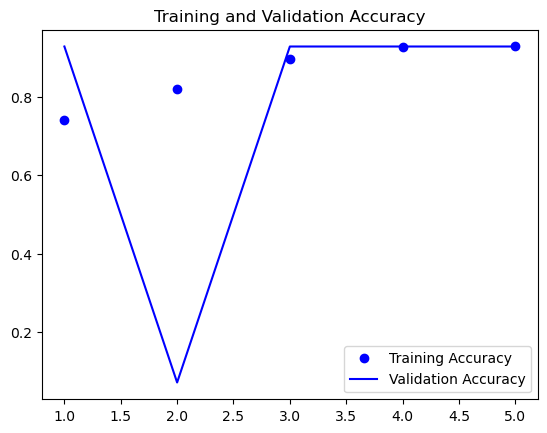

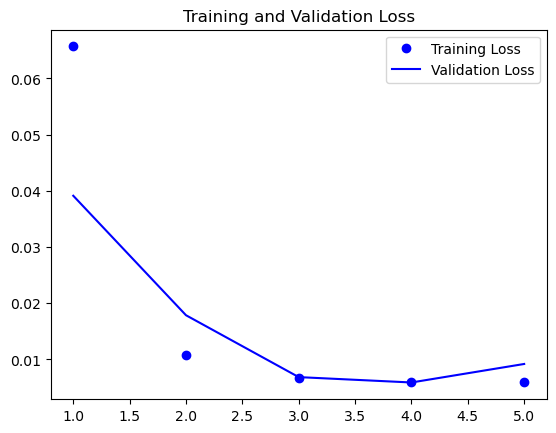

In [37]:
plot_metrics(fitted_reg_drop_binary)

In [39]:
# Make predictions
reg_drop_predictions = binary_reg_drop_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step


In [40]:
# Get the true labels
reg_drop_y_true = binary_test_generator.labels

# Convert predictions to class labels
reg_drop_y_pred = (reg_drop_predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(reg_drop_y_true, reg_drop_y_pred):.4f}")
print(f"Precision: {precision_score(reg_drop_y_true, reg_drop_y_pred):.4f}")
print(f"Recall: {recall_score(reg_drop_y_true, reg_drop_y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


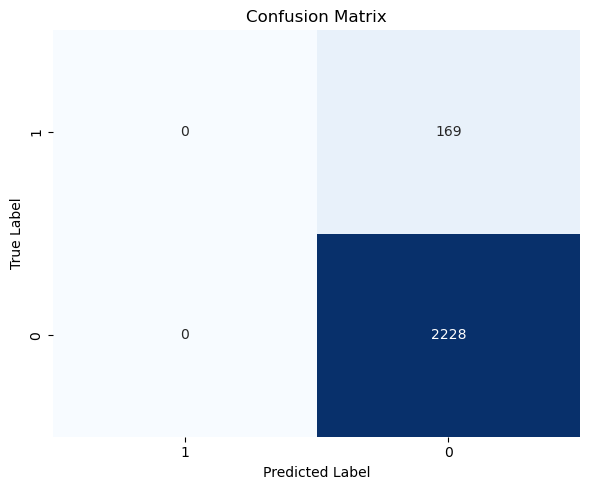

In [41]:
plot_confusion_matrix(reg_drop_y_true, reg_drop_y_pred, data['is_animal'].unique())